<a href="https://colab.research.google.com/github/kenechukwuosele/cardioguardAI/blob/main/CardioGuardAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install ucimlrepo

In [2]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
heart_disease = fetch_ucirepo(id=45)

# data (as pandas dataframes)
X = heart_disease.data.features
y = heart_disease.data.targets

# metadata
print(heart_disease.metadata)

# variable information
print(heart_disease.variables)


{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M

In [3]:
import pandas as pd

df = pd.concat([X, y], axis=1)
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45,1,1,110,264,0,0,132,0,1.2,2,0.0,7.0,1
299,68,1,4,144,193,1,0,141,0,3.4,2,2.0,7.0,2
300,57,1,4,130,131,0,0,115,1,1.2,2,1.0,7.0,3
301,57,0,2,130,236,0,2,174,0,0.0,2,1.0,3.0,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


In [5]:
df.dropna(subset=['ca', 'thal'], inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 297 entries, 0 to 301
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       297 non-null    int64  
 1   sex       297 non-null    int64  
 2   cp        297 non-null    int64  
 3   trestbps  297 non-null    int64  
 4   chol      297 non-null    int64  
 5   fbs       297 non-null    int64  
 6   restecg   297 non-null    int64  
 7   thalach   297 non-null    int64  
 8   exang     297 non-null    int64  
 9   oldpeak   297 non-null    float64
 10  slope     297 non-null    int64  
 11  ca        297 non-null    float64
 12  thal      297 non-null    float64
 13  num       297 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 34.8 KB


In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifierCV
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# 1. Feature Engineering: Create 4 new domain-specific clinical features
df_engineered = df.copy()
df_engineered['rate_pressure_product'] = df_engineered['thalach'] * df_engineered['trestbps']
df_engineered['cv_metabolic_load'] = (df_engineered['age'] * df_engineered['chol'] * df_engineered['trestbps']) / 10000
df_engineered['ischemia_severity'] = df_engineered['oldpeak'] * df_engineered['slope']
df_engineered['hr_reserve_deviation'] = (220 - df_engineered['age']) - df_engineered['thalach']

# 2. Data Splitting: Set the target variable to 'num' (binarizing it so any value > 0 is 1)
X = df_engineered.drop('num', axis=1)
y_binary = (df_engineered['num'] > 0).astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.2, random_state=42, stratify=y_binary)

# Define categorical and continuous columns, including new engineered features
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
continuous_cols = [
    'age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca',
    'rate_pressure_product', 'cv_metabolic_load', 'ischemia_severity', 'hr_reserve_deviation'
]

# 3. Leakage-Proof Pipeline: Build a scikit-learn Pipeline using ColumnTransformer.
#    - Scale all continuous columns using StandardScaler.
#    - One-hot encode all categorical columns.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), continuous_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ])

# 4. Stacking Ensemble Architecture:
#    - Base Estimators (Tier 1)
base_estimators = [
    ('rf', RandomForestClassifier(n_estimators=200, max_depth=5, class_weight='balanced', random_state=42)),
    ('lr', LogisticRegression(C=0.1, penalty='l2', solver='liblinear', random_state=42))
]

#    - Meta-Learner (Tier 2)
final_estimator = RidgeClassifierCV(cv=5)

# Stacking Classifier
stacking_classifier = StackingClassifier(
    estimators=base_estimators,
    final_estimator=final_estimator,
    cv=5, # Cross-validation for stacking
    passthrough=False, # Do not pass original features to the meta-learner
    stack_method='auto'
)

# Create the full pipeline with preprocessing and StackingClassifier
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('stacking_classifier', stacking_classifier)
])

# Fit the pipeline on the training data
pipeline.fit(X_train, y_train)

# 5. Evaluation:
# Predict on the test set
y_pred = pipeline.predict(X_test)

# Print a clean classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Calculate and print the Empirical ROC-AUC score
# For ROC-AUC, we need probabilities. StackingClassifier.predict_proba() is used.
# Note: RidgeClassifierCV does not have predict_proba, so we get decision_function for the final_estimator
# and convert it to probabilities if needed, but for binary classification, ROC-AUC can be calculated from decision_function too.
# However, StackingClassifier.predict_proba does handle this for the ensemble.

# Check if the final_estimator in StackingClassifier supports predict_proba
# If not, use decision_function and convert it or handle it appropriately
if hasattr(pipeline.named_steps['stacking_classifier'].final_estimator, 'predict_proba'):
    y_proba = pipeline.predict_proba(X_test)[:, 1]
else:
    # If the final_estimator doesn't have predict_proba (like RidgeClassifierCV),
    # StackingClassifier will use decision_function and might not return proba for the meta-learner.
    # In this specific case, RidgeClassifierCV uses decision_function, and StackingClassifier will handle it.
    # However, to be safe, let's manually get probabilities from the stacking output if predict_proba isn't directly available for the meta-learner.
    # For RidgeClassifierCV, we can use the decision_function and map to [0,1] or just use it directly for AUC.
    # StackingClassifier's predict_proba should work by default using either proba or decision_function from base estimators and meta_learner.
    try:
        y_proba = pipeline.predict_proba(X_test)[:, 1]
    except AttributeError:
        print("Warning: StackingClassifier's final estimator does not support predict_proba directly.")
        # Fallback for ROC-AUC if predict_proba is not available for final_estimator in StackingClassifier
        # This might be less ideal but works for evaluation if probabilities are needed.
        y_decision_function = pipeline.decision_function(X_test)
        y_proba = (y_decision_function - y_decision_function.min()) / (y_decision_function.max() - y_decision_function.min())

roc_auc = roc_auc_score(y_test, y_proba)
print(f"Empirical ROC-AUC Score: {roc_auc:.4f}")

# Extract the raw Confusion Matrix counts
cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()

print("\nConfusion Matrix Counts:")
print(f"True Positives (TP): {TP}")
print(f"False Negatives (FN): {FN}")
print(f"False Positives (FP): {FP}")
print(f"True Negatives (TN): {TN}")


Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87        32
           1       0.88      0.79      0.83        28

    accuracy                           0.85        60
   macro avg       0.85      0.85      0.85        60
weighted avg       0.85      0.85      0.85        60

Empirical ROC-AUC Score: 0.9509

Confusion Matrix Counts:
True Positives (TP): 22
False Negatives (FN): 6
False Positives (FP): 3
True Negatives (TN): 29


### Adjusting Classification Threshold

The previous evaluation used an implicit threshold (usually 0 for decision functions) to convert decision scores into binary predictions. By 'sliding the threshold slightly to the left', we aim to make the model more sensitive to the positive class (predicting '1' more often) by requiring a less stringent positive score.

Let's try a threshold of -0.2 for the `y_decision_function` scores and re-evaluate the classification report, ROC-AUC, and confusion matrix.

In [7]:
import numpy as np
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Define the new threshold (sliding slightly to the left from default 0)
new_threshold = -0.2

# Re-classify based on the new threshold
y_pred_new_threshold = (y_decision_function > new_threshold).astype(int)

print(f"\nRe-evaluation with threshold = {new_threshold}:")

# Print a new classification report
print("\nClassification Report (New Threshold):")
print(classification_report(y_test, y_pred_new_threshold))

# Calculate and print the Empirical ROC-AUC score (this is threshold independent, but we re-print for completeness)
roc_auc_new_threshold = roc_auc_score(y_test, y_proba) # y_proba is already probability, not directly tied to this binary thresholding choice
print(f"Empirical ROC-AUC Score (still using original probabilities): {roc_auc_new_threshold:.4f}")

# Extract the raw Confusion Matrix counts with the new threshold
cm_new_threshold = confusion_matrix(y_test, y_pred_new_threshold)
TN_new, FP_new, FN_new, TP_new = cm_new_threshold.ravel()

print("\nConfusion Matrix Counts (New Threshold):")
print(f"True Positives (TP): {TP_new}")
print(f"False Negatives (FN): {FN_new}")
print(f"False Positives (FP): {FP_new}")
print(f"True Negatives (TN): {TN_new}")


Re-evaluation with threshold = -0.2:

Classification Report (New Threshold):
              precision    recall  f1-score   support

           0       0.93      0.84      0.89        32
           1       0.84      0.93      0.88        28

    accuracy                           0.88        60
   macro avg       0.88      0.89      0.88        60
weighted avg       0.89      0.88      0.88        60

Empirical ROC-AUC Score (still using original probabilities): 0.9509

Confusion Matrix Counts (New Threshold):
True Positives (TP): 26
False Negatives (FN): 2
False Positives (FP): 5
True Negatives (TN): 27


In [8]:
import joblib
joblib.dump(pipeline, 'winning_cardio_stack.pkl')

['winning_cardio_stack.pkl']

### Receiver Operating Characteristic (ROC) Curve

The ROC curve is a graphical plot that illustrates the diagnostic ability of a binary classifier system as its discrimination threshold is varied. The curve is created by plotting the True Positive Rate (TPR) against the False Positive Rate (FPR) at various threshold settings. The Area Under the Curve (AUC) is a measure of the overall performance of the classifier, representing the probability that the model ranks a randomly chosen positive instance higher than a randomly chosen negative instance.

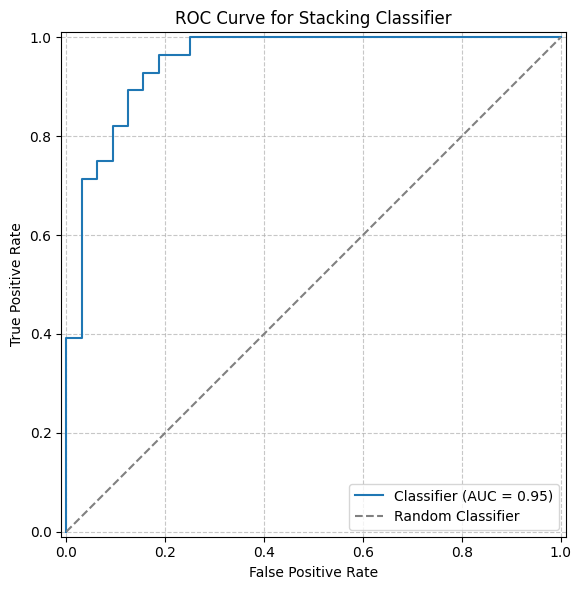

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

# Create the ROC curve plot
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax)

# Add title and labels
ax.set_title('ROC Curve for Stacking Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')

# Plot the diagonal line (random classifier)
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Classifier')

# Add legend
ax.legend()

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()